In [33]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier,export_graphviz
import graphviz
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [34]:
df=pd.read_csv('data/heart.csv')
df.head(3)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [36]:
y=df['target']
x=df.drop("target",axis=1)


In [37]:
forest=RandomForestClassifier()
model=forest.fit(x,y)
model.score(x,y)

1.0

In [38]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=16,train_size=0.70)

In [39]:
forest=RandomForestClassifier(n_estimators=400,max_depth=4)
model=forest.fit(x_train,y_train)
model.score(x_test,y_test)

0.8831168831168831

In [40]:
model.predict([[31,1,2,130,240,0,0,150,0,2,0,0,2]])

c:\Users\hp\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([1], dtype=int64)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


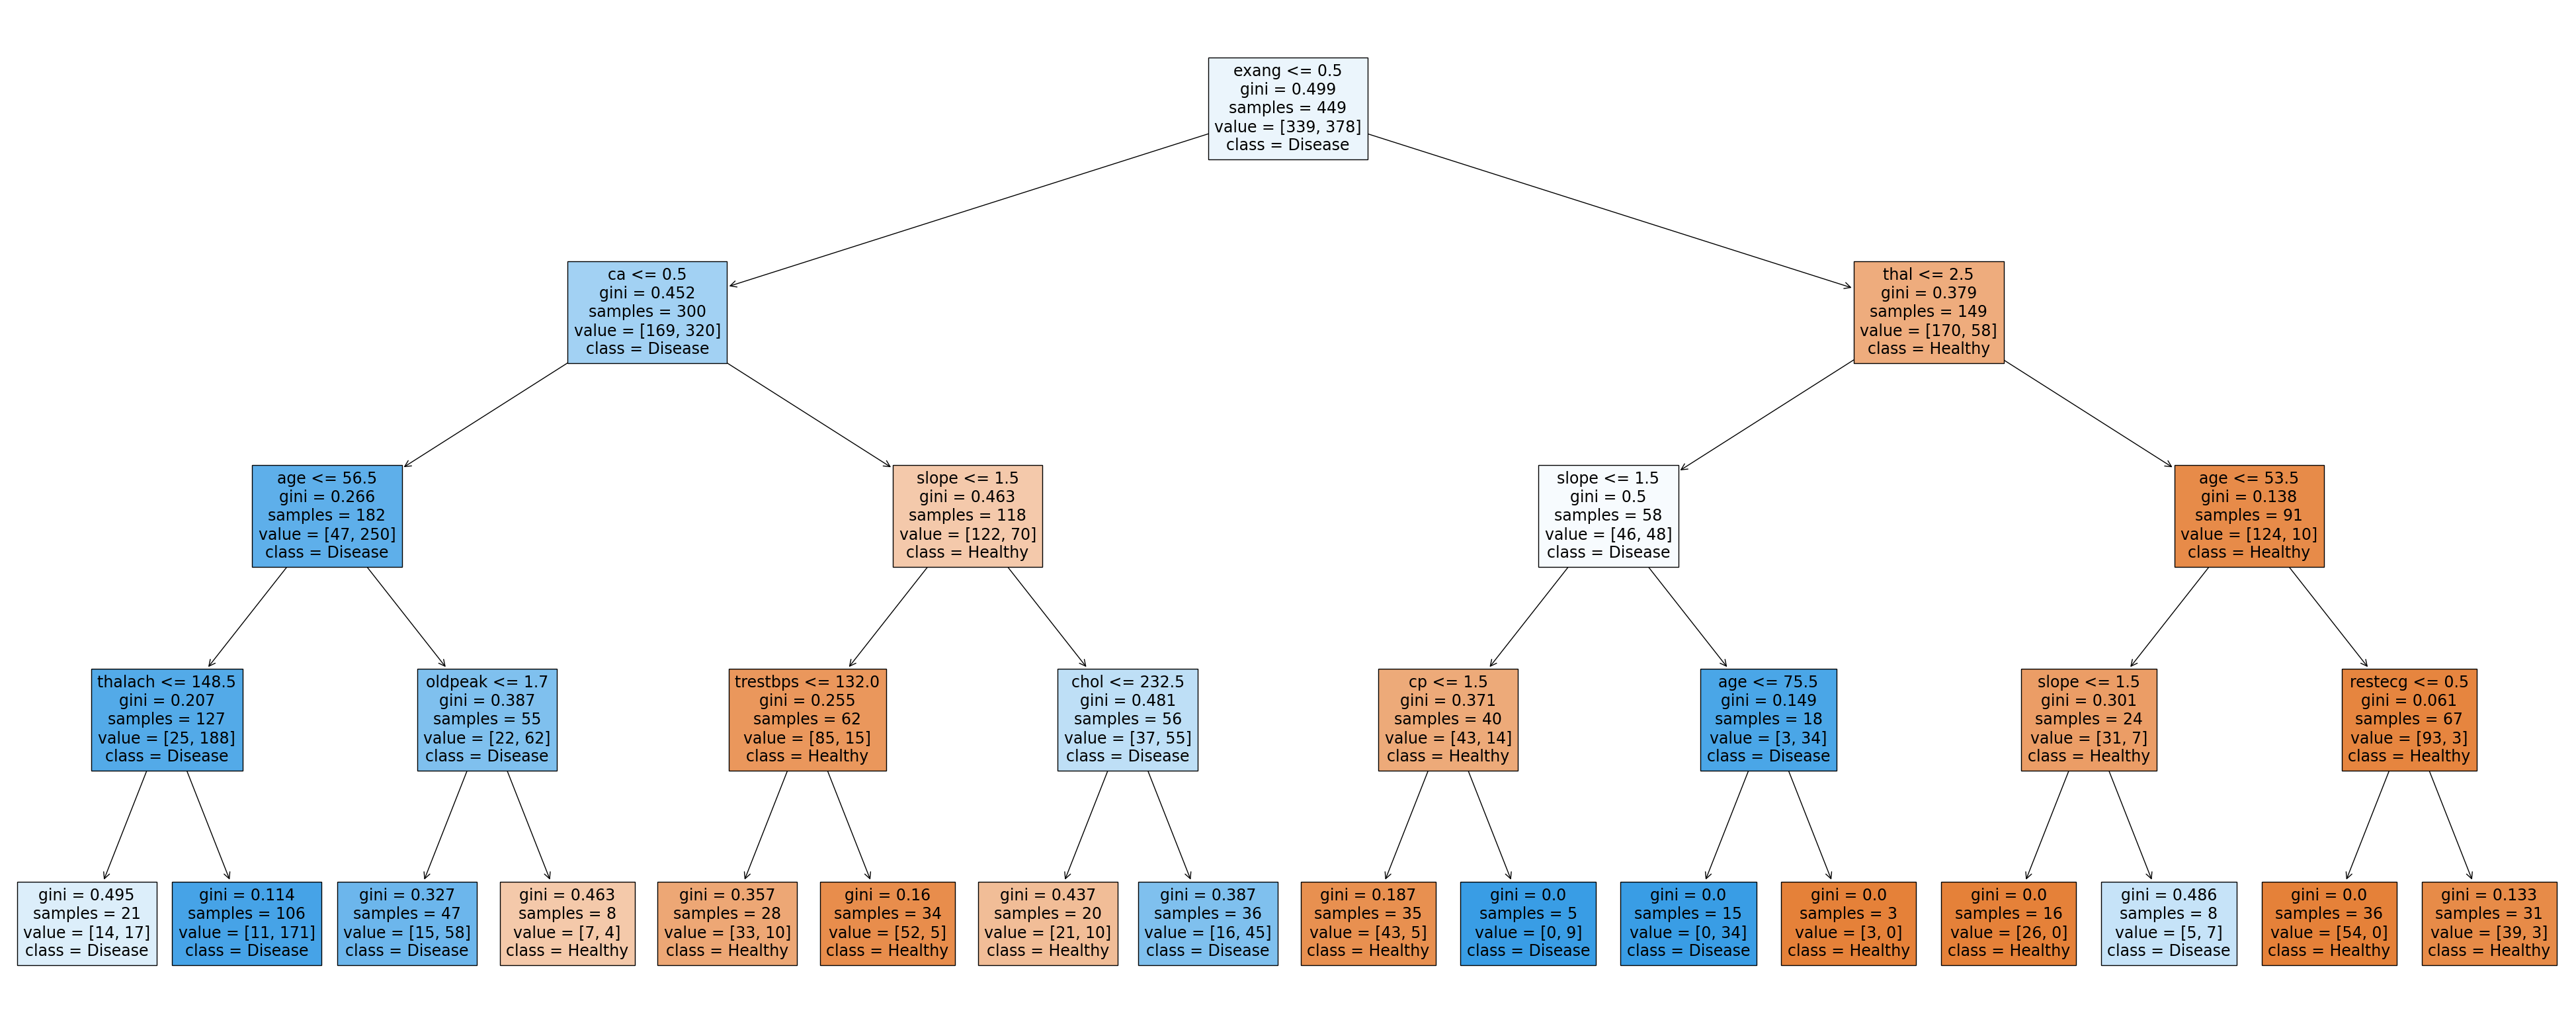

In [42]:
from sklearn import tree
import matplotlib.pyplot as plt

# Random Forest içindeki ilk karar ağacını görselle
plt.figure(figsize=(50,20))
tree.plot_tree(model.estimators_[0], 
               feature_names=x.columns,
               class_names=['Healthy', 'Disease'],
               filled=True)
plt.show()

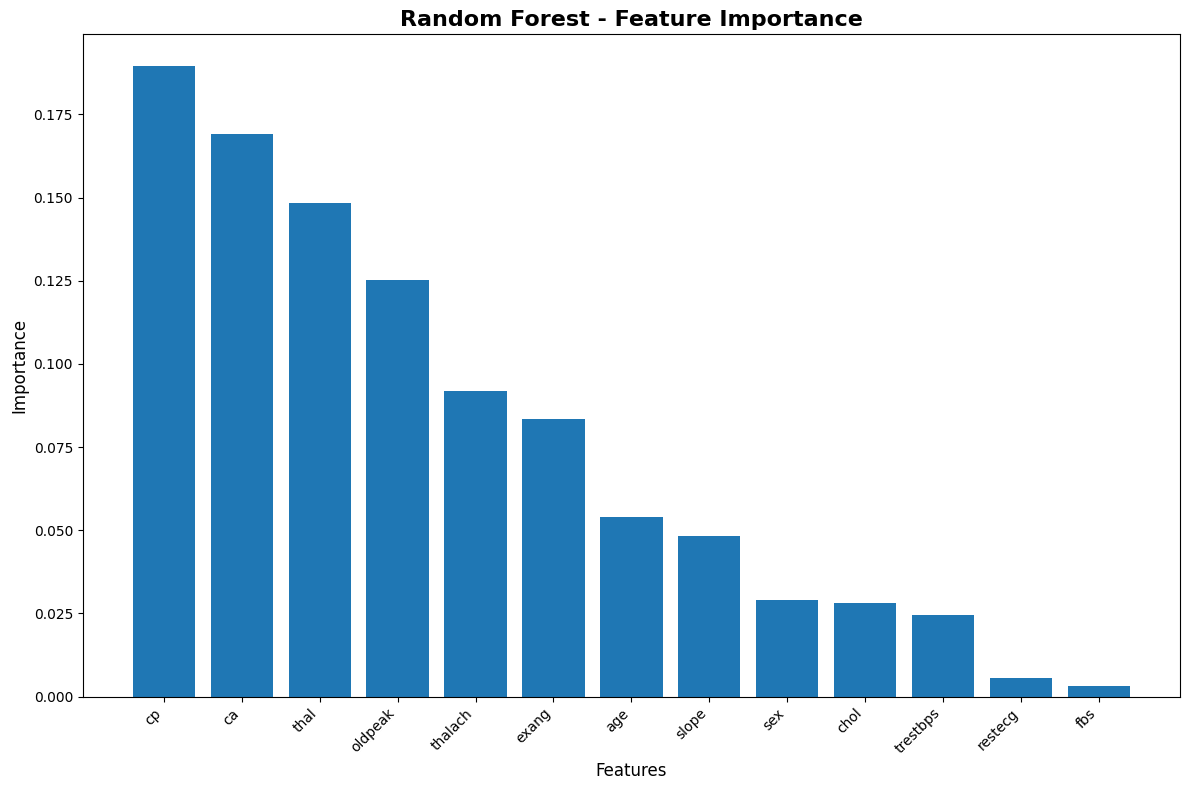

 Feature  Importance
      cp    0.189597
      ca    0.169149
    thal    0.148457
 oldpeak    0.125280
 thalach    0.091765
   exang    0.083338
     age    0.053958
   slope    0.048109
     sex    0.029105
    chol    0.027987
trestbps    0.024418
 restecg    0.005599
     fbs    0.003237


In [43]:
# Random Forest Feature Importance Grafiği
import matplotlib.pyplot as plt

# Feature importance değerlerini al
feature_importance = model.feature_importances_
features = x.columns

# Sıralamak için indeks oluştur
indices = np.argsort(feature_importance)[::-1]

# Grafiği çiz
plt.figure(figsize=(12, 8))
plt.title('Random Forest - Feature Importance', fontsize=16, fontweight='bold')
plt.bar(range(len(feature_importance)), feature_importance[indices], align='center')
plt.xticks(range(len(feature_importance)), features[indices], rotation=45, ha='right')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Importance', fontsize=12)
plt.tight_layout()
plt.show()

# Tablo olarak da göster
importance_df = pd.DataFrame({
    'Feature': features[indices],
    'Importance': feature_importance[indices]
})
print(importance_df.to_string(index=False))